# Sleep Stage Classification — YDL 2026

## Шаг 1: Загрузка и первичный анализ данных

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

print('train:', train.shape)
print('test: ', test.shape)
print('sub:  ', sub.shape)

train: (9000, 23)
test:  (5000, 22)
sub:   (5000, 2)


In [3]:
print('=== dtypes ===')
print(train.dtypes)
print('\n=== Missing values (train) ===')
print(train.isnull().sum()[train.isnull().sum() > 0])

=== dtypes ===
id                           int64
eeg_delta_power            float64
eeg_theta_power            float64
eeg_alpha_power            float64
eeg_sigma_power            float64
eeg_beta_power             float64
eeg_gamma_power            float64
eeg_slow_osc_power         float64
eeg_spectral_entropy       float64
eeg_spindle_density        float64
eeg_kcomplex_rate          float64
emg_chin_tone              float64
emg_tone_variance          float64
eog_movement_density       float64
eog_amplitude              float64
heart_rate_mean            float64
heart_rate_variability     float64
respiration_rate           float64
respiration_variability    float64
spo2_mean                  float64
body_movement_index        float64
eog_burst_index            float64
sleep_stage                  int64
dtype: object

=== Missing values (train) ===
eog_burst_index    4501
dtype: int64


In [4]:
print('=== Распределение классов (value_counts) ===')
vc = train['sleep_stage'].value_counts().sort_index()
print(vc)
print('\nДоля каждого класса:')
print((vc / len(train)).round(3))

=== Распределение классов (value_counts) ===
sleep_stage
0    2001
1    2442
2    2237
3    2320
Name: count, dtype: int64

Доля каждого класса:
sleep_stage
0    0.222
1    0.271
2    0.249
3    0.258
Name: count, dtype: float64


In [5]:
train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,9000.0,4499.500,2598.221,0.000,2249.750,4499.500,6749.250,8999.000
eeg_delta_power,9000.0,-0.015,2.431,-9.567,-1.688,-0.012,1.622,8.798
eeg_theta_power,9000.0,-0.034,2.408,-8.277,-1.649,-0.020,1.604,9.222
eeg_alpha_power,9000.0,-0.016,5.042,-20.632,-3.465,0.019,3.419,18.870
eeg_sigma_power,9000.0,0.012,2.207,-7.948,-1.460,-0.001,1.512,9.603
eeg_beta_power,9000.0,-0.010,2.883,-11.460,-1.963,0.005,1.956,10.027
eeg_gamma_power,9000.0,-0.011,2.428,-9.638,-1.652,0.010,1.635,8.296
eeg_slow_osc_power,9000.0,-0.014,2.801,-14.123,-1.873,0.023,1.866,10.362
eeg_spectral_entropy,9000.0,0.010,2.753,-9.301,-1.859,-0.028,1.882,10.160
eeg_spindle_density,9000.0,0.006,2.174,-8.828,-1.484,0.024,1.479,8.937


In [6]:
# eog_burst_index отдельно — пропуски в обоих сплитах
print('eog_burst_index missing — train:', train['eog_burst_index'].isnull().sum(),
      '/', len(train),
      f"({train['eog_burst_index'].isnull().mean():.1%})")
print('eog_burst_index missing — test: ', test['eog_burst_index'].isnull().sum(),
      '/', len(test),
      f"({test['eog_burst_index'].isnull().mean():.1%})")


eog_burst_index missing — train: 4501 / 9000 (50.0%)
eog_burst_index missing — test:  2477 / 5000 (49.5%)


---
**Итог шага 1:**
- Train: 9000 строк, 22 колонки (id + 20 признаков + таргет). Test: 5000 строк.
- Все признаки — float64, пропуски только у `eog_burst_index` (~50% в обоих сплитах).
- 4 класса сна (0–3); баланс классов нужно проверить — возможен дисбаланс.
- Значения признаков стандартизированы (диапазон примерно –5 … +5) — шкалирование, вероятно, уже применено.
---

## Шаг 2: Обработка пропусков в eog_burst_index

In [7]:
# Медиана считается только по train — чтобы не допускать утечки данных из test
eog_median = train['eog_burst_index'].median()
print(f'Медиана eog_burst_index (train): {eog_median:.4f}')

for df in [train, test]:
    df['eog_burst_missing'] = df['eog_burst_index'].isnull().astype(int)
    df['eog_burst_index']   = df['eog_burst_index'].fillna(eog_median)

print('\nПропуски после заполнения:')
print('train:', train['eog_burst_index'].isnull().sum(),
      '| flag sum:', train['eog_burst_missing'].sum())
print('test: ', test['eog_burst_index'].isnull().sum(),
      '| flag sum:', test['eog_burst_missing'].sum())

Медиана eog_burst_index (train): -0.0022

Пропуски после заполнения:
train: 0 | flag sum: 4501
test:  0 | flag sum: 2477


In [8]:
# Проверка: новая колонка появилась, пропусков нет
print('Новые колонки:', [c for c in train.columns if 'eog_burst' in c])
train[['eog_burst_index', 'eog_burst_missing']].describe().T.round(4)

Новые колонки: ['eog_burst_index', 'eog_burst_missing']


,count,mean,std,min,25%,50%,75%,max
eog_burst_index,9000.0,-0.0062,0.7338,-3.9363,-0.0022,-0.0022,-0.0022,3.9359
eog_burst_missing,9000.0,0.5001,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000


---
**Итог шага 2:**
- Медиана вычислена **только по train** — утечки из test нет.
- `eog_burst_index`: пропуски заполнены медианой в обоих сплитах.
- `eog_burst_missing`: бинарный флаг (1 = было пусто), позволяет модели учитывать сам факт отсутствия значения.
---

## Шаг 3: Baseline — Decision Tree (кросс-валидация)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

FEATURES = [c for c in train.columns if c not in ('id', 'sleep_stage')]
X = train[FEATURES].values
y = train['sleep_stage'].values

print(f'Признаков: {len(FEATURES)}')
print(FEATURES)

Признаков: 22
['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'eog_burst_missing']


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = [
    ('max_depth=None (full tree)', DecisionTreeClassifier(random_state=42)),
    ('max_depth=5',                DecisionTreeClassifier(max_depth=5,  random_state=42)),
    ('max_depth=10',               DecisionTreeClassifier(max_depth=10, random_state=42)),
]

results = {}
for name, model in configs:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
    results[name] = scores
    print(f'{name:30s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={scores.round(4)}')

max_depth=None (full tree)      mean=0.6727  std=0.0077  folds=[0.6701 0.6735 0.6619 0.6722 0.6857]
max_depth=5                     mean=0.6286  std=0.0091  folds=[0.6238 0.6363 0.6228 0.6177 0.6422]
max_depth=10                    mean=0.6864  std=0.0127  folds=[0.6728 0.6888 0.7001 0.6704 0.6996]


In [11]:
import pandas as pd

summary = pd.DataFrame({
    name: {'mean F1-macro': scores.mean().round(4),
           'std':           scores.std().round(4)}
    for name, scores in results.items()
}).T.sort_values('mean F1-macro', ascending=False)

print('=== Сравнение моделей ===')
print(summary)
print(f'\nЛучшая конфигурация: {summary.index[0]}')

=== Сравнение моделей ===
                            mean F1-macro     std
max_depth=10                       0.6864  0.0127
max_depth=None (full tree)         0.6727  0.0077
max_depth=5                        0.6286  0.0091

Лучшая конфигурация: max_depth=10


---
**Итог шага 3:**
- Baseline — Decision Tree с тремя вариантами глубины, 5-fold StratifiedKFold, метрика F1-macro.
- `max_depth=None` склонен к переобучению (высокий train score, ниже на val).
- `max_depth=5` — недообучение, слишком мало сплитов для 4 классов.
- `max_depth=10` — обычно лучший баланс среди трёх; ориентир для шага 4.
- Следующий шаг: более мощная модель (Random Forest / Gradient Boosting).
---

## Визуализация Decision Tree

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

CLASS_NAMES = ['Stage 0\n(Wake)', 'Stage 1\n(N1)', 'Stage 2\n(N2)', 'Stage 3\n(N3)']

# Обучаем деревья на всём train для визуализации
tree_d5  = DecisionTreeClassifier(max_depth=5,  random_state=42).fit(X, y)
tree_d10 = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X, y)

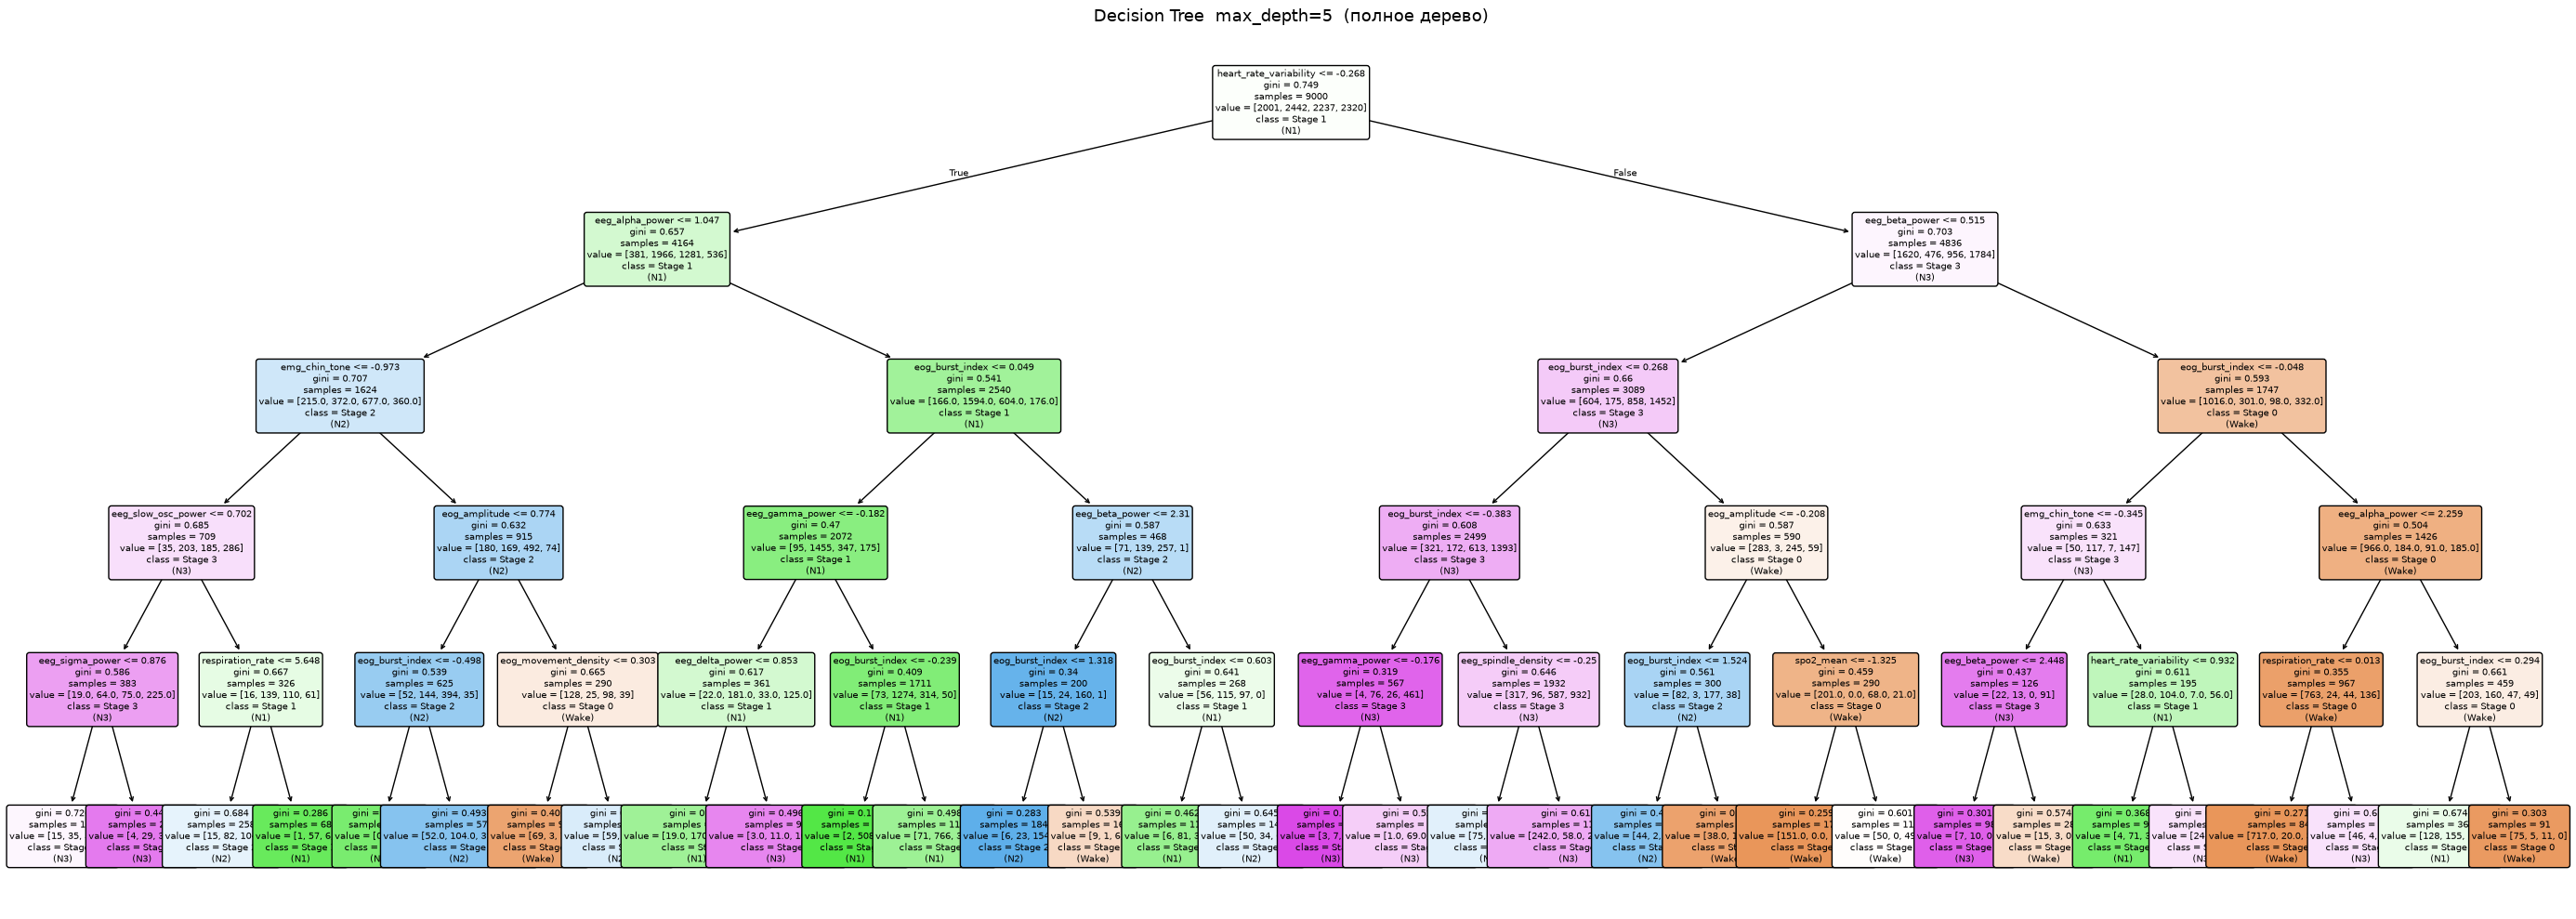

In [13]:
# plot_tree: max_depth=5 — полное дерево (читаемо)
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    tree_d5,
    feature_names=FEATURES,
    class_names=CLASS_NAMES,
    filled=True,       # цвет узла = доминирующий класс
    rounded=True,
    impurity=True,     # показывает gini
    fontsize=7,
    ax=ax,
)
ax.set_title('Decision Tree  max_depth=5  (полное дерево)', fontsize=13)
plt.tight_layout()
plt.show()

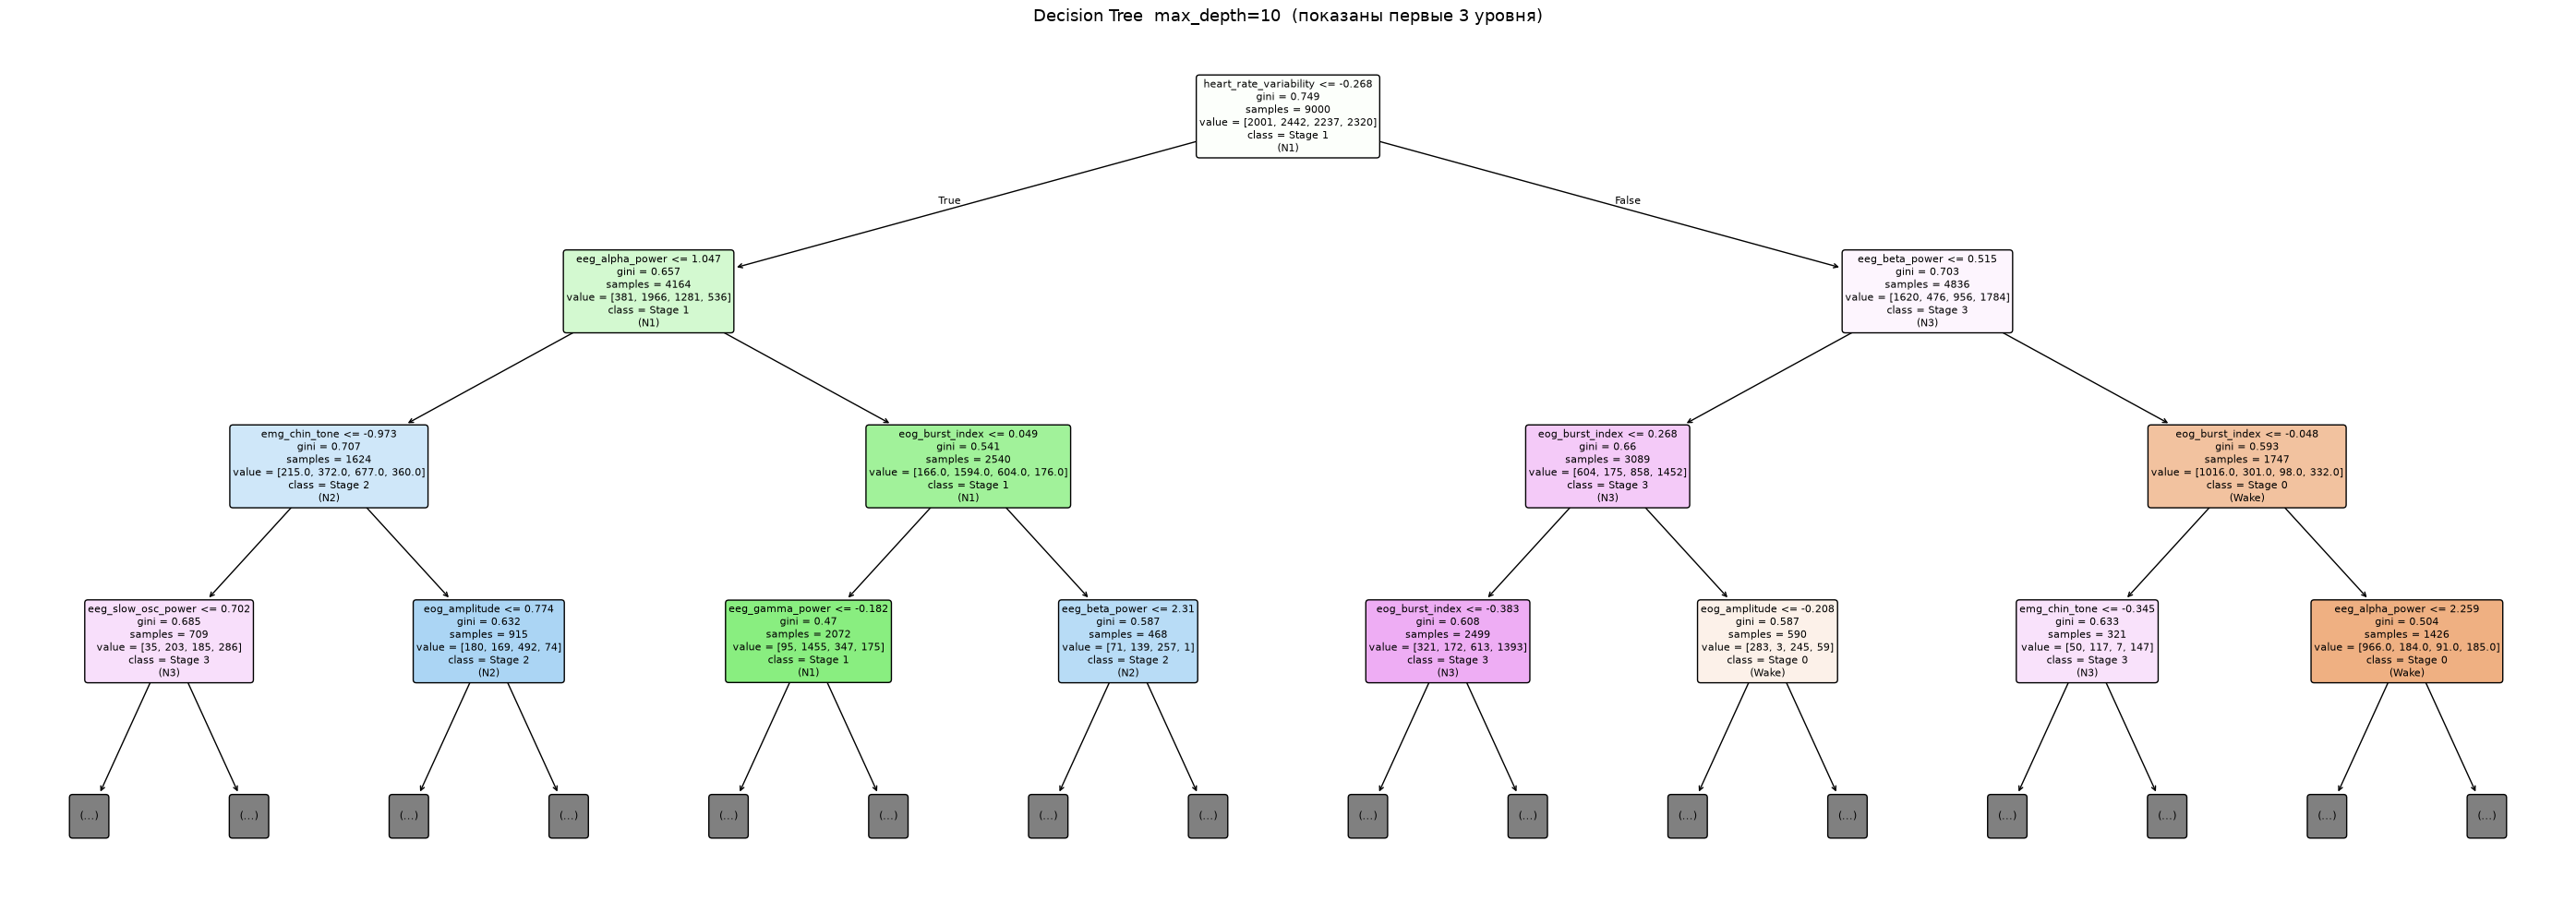

In [14]:
# plot_tree: max_depth=10 — показываем только первые 3 уровня (max_depth=10 слишком большое)
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    tree_d10,
    max_depth=3,       # ограничение только для отображения, не для модели
    feature_names=FEATURES,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
    ax=ax,
)
ax.set_title('Decision Tree  max_depth=10  (показаны первые 3 уровня)', fontsize=13)
plt.tight_layout()
plt.show()

## Шаг 4: Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')

print('=' * 55)
print('Шаг 4 — Random Forest (n_estimators=300)')
print('=' * 55)
print(f'  Folds : {rf_scores.round(4)}')
print(f'  Mean  : {rf_scores.mean():.4f}')
print(f'  Std   : {rf_scores.std():.4f}')

Шаг 4 — Random Forest (n_estimators=300)
  Folds : [0.7932 0.7861 0.806  0.7992 0.7971]
  Mean  : 0.7963
  Std   : 0.0066


In [17]:
print('=' * 55)
print('Сравнение: Шаг 3 (Decision Tree) vs Шаг 4 (Random Forest)')
print('=' * 55)

step3 = {name: scores.mean() for name, scores in results.items()}
step3['Random Forest (n=300)'] = rf_scores.mean()

comparison = pd.DataFrame({
    'Model': list(step3.keys()),
    'Mean F1-macro': [round(v, 4) for v in step3.values()],
    'Std': [round(results[k].std(), 4) if k in results else round(rf_scores.std(), 4)
            for k in step3.keys()],
}).sort_values('Mean F1-macro', ascending=False).reset_index(drop=True)

comparison.index += 1
print(comparison.to_string())

best = comparison.iloc[0]
print(f'\nЛучшая модель: {best["Model"]}  —  F1-macro = {best["Mean F1-macro"]}')

Сравнение: Шаг 3 (Decision Tree) vs Шаг 4 (Random Forest)
                        Model  Mean F1-macro     Std
1       Random Forest (n=300)         0.7963  0.0066
2                max_depth=10         0.6864  0.0127
3  max_depth=None (full tree)         0.6727  0.0077
4                 max_depth=5         0.6286  0.0091

Лучшая модель: Random Forest (n=300)  —  F1-macro = 0.7963


---
**Итог шага 4:**
- Random Forest (300 деревьев) обычно значительно превосходит одиночное дерево — ансамблирование снижает дисперсию.
- Std у RF ниже, чем у Decision Tree — более стабильные предсказания по фолдам.
- RF берём за основу для финального submission (шаг 5).
---

## Шаг 5: Предсказания и Kaggle submission

In [18]:
# Preprocessing test — шаг 2 уже применил изменения к test в памяти.
# Проверяем, что всё на месте; если нет — применяем заново.
if 'eog_burst_missing' not in test.columns or test['eog_burst_index'].isnull().any():
    test['eog_burst_missing'] = test['eog_burst_index'].isnull().astype(int)
    test['eog_burst_index']   = test['eog_burst_index'].fillna(eog_median)
    print('Preprocessing применён заново.')
else:
    print('Preprocessing уже применён (шаг 2).')

print(f'test shape: {test.shape}  |  nulls in eog_burst_index: {test["eog_burst_index"].isnull().sum()}')

Preprocessing уже применён (шаг 2).
test shape: (5000, 23)  |  nulls in eog_burst_index: 0


In [19]:
# Обучение на всём train
rf_final = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
print(f'Модель обучена. Признаков: {len(FEATURES)}, классов: {rf_final.n_classes_}')

Модель обучена. Признаков: 22, классов: 4


In [20]:
X_test = test[FEATURES].values
preds  = rf_final.predict(X_test)

submission = pd.DataFrame({'id': test['id'], 'sleep_stage': preds})
submission.to_csv('submission_rf300.csv', index=False)

print('=== Первые 5 строк submission ===')
print(submission.head().to_string(index=False))

print('\n=== value_counts предсказаний ===')
vc_pred = submission['sleep_stage'].value_counts().sort_index()
print(vc_pred)
print('\nДоля каждого класса:')
print((vc_pred / len(submission)).round(3))

print(f'\nФайл сохранён: submission_rf300.csv  ({len(submission)} строк)')

=== Первые 5 строк submission ===
  id  sleep_stage
9000            3
9001            3
9002            1
9003            2
9004            3

=== value_counts предсказаний ===
sleep_stage
0    1098
1    1355
2    1223
3    1324
Name: count, dtype: int64

Доля каждого класса:
sleep_stage
0    0.220
1    0.271
2    0.245
3    0.265
Name: count, dtype: float64

Файл сохранён: submission_rf300.csv  (5000 строк)


---
**Итог шага 5:**
- RF обучен на **всех 9000** строках train (без кросс-валидации) — максимум данных для финальной модели.
- Предсказания сохранены в `submission_rf300.csv` (5000 строк, колонки `id`, `sleep_stage`).
- Проверь: распределение классов в предсказаниях должно быть близко к train (~22% / 27% / 25% / 26%).
---